In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
data = pd.read_csv("../data/house_data.csv")

In [3]:
data.head()

,Area,Bedrooms,Bathrooms,Age,Parking,Location,Price
0,3219,1,1,23,1,Pune,28102000
1,1514,2,1,21,2,Kalyan,13962000
2,956,5,4,1,0,Mumbai,16298000
3,1495,2,1,17,0,Kalyan,13610000
4,2318,2,4,18,1,Mumbai,25044000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       1000 non-null   int64
 1   Bedrooms   1000 non-null   int64
 2   Bathrooms  1000 non-null   int64
 3   Age        1000 non-null   int64
 4   Parking    1000 non-null   int64
 5   Location   1000 non-null   str  
 6   Price      1000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 61.0 KB


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       1000 non-null   int64
 1   Bedrooms   1000 non-null   int64
 2   Bathrooms  1000 non-null   int64
 3   Age        1000 non-null   int64
 4   Parking    1000 non-null   int64
 5   Location   1000 non-null   str  
 6   Price      1000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 61.0 KB


In [6]:
data.shape

(1000, 7)

In [7]:
data.describe()

,Area,Bedrooms,Bathrooms,Age,Parking,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2316.134000,3.077000,2.528000,15.517000,1.032000,2.279932e+07
std,972.986137,1.401083,1.110157,8.858001,0.824412,7.880257e+06
min,602.000000,1.000000,1.000000,0.000000,0.000000,7.212000e+06
25%,1494.000000,2.000000,2.000000,8.000000,0.000000,1.613450e+07
50%,2321.000000,3.000000,3.000000,16.000000,1.000000,2.294200e+07
75%,3120.750000,4.000000,4.000000,23.000000,2.000000,2.924850e+07
max,3999.000000,5.000000,4.000000,30.000000,2.000000,4.029200e+07


In [8]:
data.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Age          0
Parking      0
Location     0
Price        0
dtype: int64

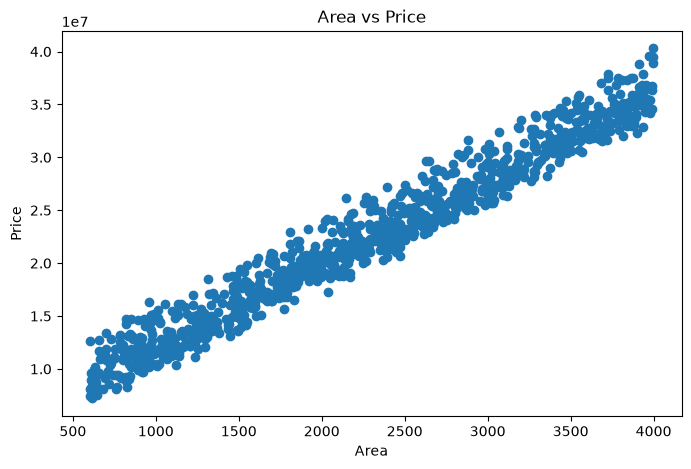

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(data["Area"], data["Price"])

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

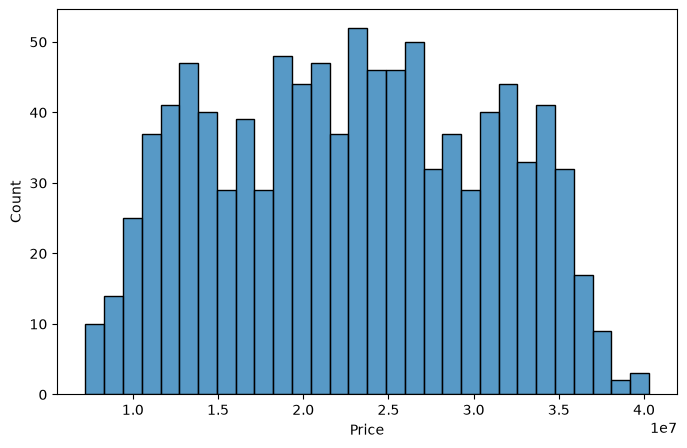

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(data["Price"], bins=30)

plt.show()

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(data.corr(), annot=True)

plt.show()

ValueError: could not convert string to float: 'Pune'

<Figure size 800x600 with 0 Axes>

In [12]:
numeric_data = data.select_dtypes(include=['number'])

numeric_data.corr()

,Area,Bedrooms,Bathrooms,Age,Parking,Price
Area,1.000000,-0.017402,-0.023925,0.041320,0.014236,0.979479
Bedrooms,-0.017402,1.000000,-0.026164,0.036794,0.003064,0.065771
Bathrooms,-0.023925,-0.026164,1.000000,-0.008141,0.048237,0.025107
Age,0.041320,0.036794,-0.008141,1.000000,0.024187,-0.012965
Parking,0.014236,0.003064,0.048237,0.024187,1.000000,0.037113
Price,0.979479,0.065771,0.025107,-0.012965,0.037113,1.000000


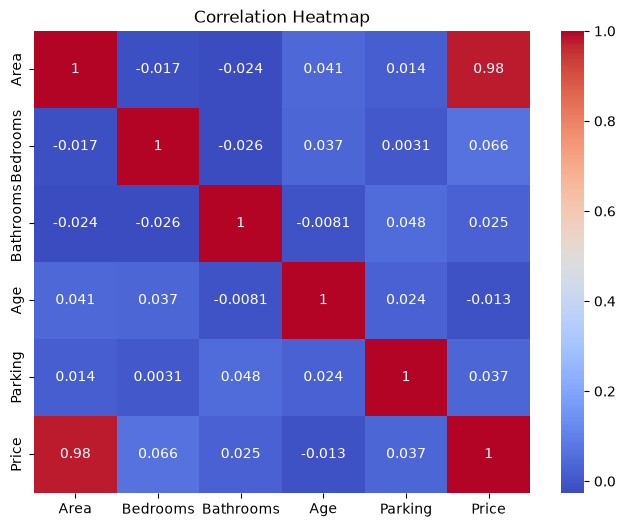

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [14]:
data.dtypes

Area         int64
Bedrooms     int64
Bathrooms    int64
Age          int64
Parking      int64
Location       str
Price        int64
dtype: object

In [15]:
data = pd.get_dummies(data, columns=["Location"], drop_first=True)

In [16]:
data.head()

,Area,Bedrooms,Bathrooms,Age,Parking,Price,Location_Mumbai,Location_Navi Mumbai,Location_Pune,Location_Thane
0,3219,1,1,23,1,28102000,False,False,True,False
1,1514,2,1,21,2,13962000,False,False,False,False
2,956,5,4,1,0,16298000,True,False,False,False
3,1495,2,1,17,0,13610000,False,False,False,False
4,2318,2,4,18,1,25044000,True,False,False,False


In [17]:
X = data.drop("Price", axis=1)

y = data["Price"]

In [20]:
X.head()

,Area,Bedrooms,Bathrooms,Age,Parking,Location_Mumbai,Location_Navi Mumbai,Location_Pune,Location_Thane
0,3219,1,1,23,1,False,False,True,False
1,1514,2,1,21,2,False,False,False,False
2,956,5,4,1,0,True,False,False,False
3,1495,2,1,17,0,False,False,False,False
4,2318,2,4,18,1,True,False,False,False


In [22]:
y.head()

0    28102000
1    13962000
2    16298000
3    13610000
4    25044000
Name: Price, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (800, 9)
Testing Data : (200, 9)


In [25]:
print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Labels: (800,)
Testing Labels : (200,)


In [26]:
X_train.head()

,Area,Bedrooms,Bathrooms,Age,Parking,Location_Mumbai,Location_Navi Mumbai,Location_Pune,Location_Thane
29,837,2,1,2,2,False,True,False,False
535,3812,2,4,11,1,True,False,False,False
695,3814,4,4,15,2,False,False,False,True
557,2802,3,2,24,1,False,False,False,False
836,1644,1,3,14,2,False,False,True,False


In [27]:
X_test.head()

,Area,Bedrooms,Bathrooms,Age,Parking,Location_Mumbai,Location_Navi Mumbai,Location_Pune,Location_Thane
521,1066,5,2,18,2,False,False,True,False
737,1734,3,3,6,0,False,False,False,False
740,1810,3,4,12,1,True,False,False,False
660,2785,1,2,18,1,False,False,False,True
411,1580,2,1,21,2,False,False,True,False


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 8000., 500000., 300000.,...,1000000.,1300000., 600000.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area','Bedrooms','Bathrooms',...,'Location_Navi Mumbai','Location_Pune', 'Location_Thane']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.2e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [31]:
print(model.coef_)

[   8000.  500000.  300000.  -50000.  200000. 3800000. 1000000. 1300000.
  600000.]


In [32]:
print(model.intercept_)

1200000.000000015


In [34]:
predictions = model.predict(X_test)

In [35]:
print(predictions[:10])

[13628000.00000003 17172000.         21780000.         24480000.
 15790000.00000002 19060000.00000001 11876000.00000003 17790000.00000001
 27272000.         30513999.99999999]


In [36]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,13628000,13628000.0
1,17172000,17172000.0
2,21780000,21780000.0
3,24480000,24480000.0
4,15790000,15790000.0
5,19060000,19060000.0
6,11876000,11876000.0
7,17790000,17790000.0
8,27272000,27272000.0
9,30514000,30514000.0


In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [38]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 1.8388964235782624e-08


In [39]:
mse = mean_squared_error(y_test, predictions)

print("MSE:", mse)

MSE: 5.154600704604384e-16


In [40]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2.270374573634136e-08


In [41]:
r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 1.0


In [42]:
print("Model Evaluation")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
-------------------------
MAE : 1.8388964235782624e-08
MSE : 5.154600704604384e-16
RMSE: 2.270374573634136e-08
R² Score: 1.0


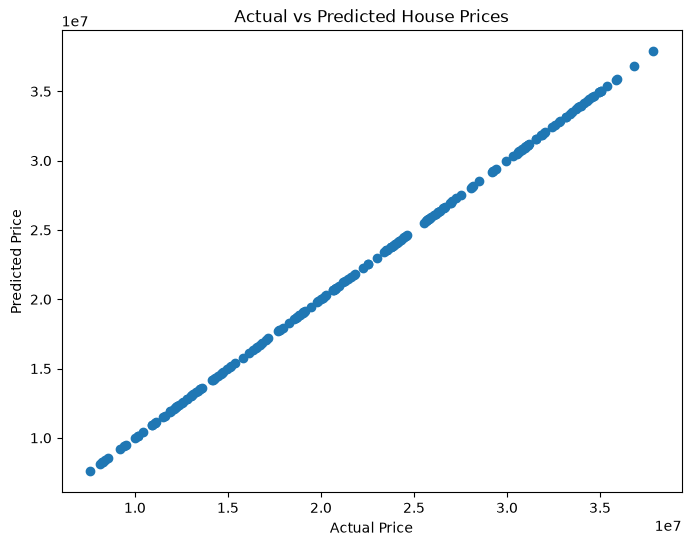

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [44]:
import joblib

joblib.dump(model, "models/house_price_model.pkl")

print("Model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/house_price_model.pkl'

In [45]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 8000., 500000., 300000.,...,1000000.,1300000., 600000.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Area','Bedrooms','Bathrooms',...,'Location_Navi Mumbai','Location_Pune', 'Location_Thane']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.2e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
